TABLEAU A CONSTRUIRE

* lignes : INDEX 1 = dataset/model ; INDEX 2 = $\kappa_f$ ; INDEX 3 = 'hyperparameter value': n=... puis imbalance=... puis $\delta$=... 

* colonnes = normalized Areas Between Curves (ABC, between bounds curve and test metric curve, normalized by number of common $\theta$ points on x-axis): R0/1, R0/1, FPP, FPP, ..., moyennes calculées sur 10 splits de CV



In [1]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
from IPython.display import clear_output
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.plotting import *
from python_scripts.preprocessing import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


In [ ]:
datasets_paths = [
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/CIFAR2/sgp_set_cnn',
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/CIFAR2/sgp_set_resnet',
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/CIFAR2/sgp_set_cnn_MCD',
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/WSI/sgp_set_cnn',
    'C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/WSI/sgp_set_cnn_MCD'
]

In [ ]:
dicos = []
datasets = ['BC', 'CIFAR2', 'WSI']
models = ["log_reg", "cnn", "resnet"]

for path in datasets_paths:

    print('Considering ', path)
    mod = models[int(np.where([(m in path) for m in models])[0][0])]
    ds = datasets[int(np.where([(d in path) for d in datasets])[0][0])]
    if 'MCD' in path:
        kappa = 'MCD'
    else:
        kappa = 'SR'

    original_ds = pickle.load(open(path, 'rb'))

    print('Sample size proportions...')
    for prop in np.linspace(1/4,1,num=6):
        print('prop = ', prop)
        for metric in ['standard', 'FP', 'FN', 'FPR', 'FNR']:
            print("metric = ", metric)
            values = []
            for seed in tqdm(range(20)):
                df = original_ds.sample(frac=prop, random_state=seed)
                values.append(ABC(df, metric=metric))
            dicos.append({'dataset': ds,
                            'model': mod,
                            'kappa': kappa,
                            'metric': metric,
                            'param.': 'N',
                            'value': prop,
                            'ABC': np.mean(values),
                            'CI': [np.mean(values)-1.96*np.std(values),
                                np.mean(values)+1.96*np.std(values)]})

    print('Imbalance rates...')
    for imbalance in np.linspace(1/6,5/6,num=5):
        print('imbalance = ', imbalance)
        for metric in ['standard', 'FP', 'FN', 'FPR', 'FNR']:
            print('metric = ', metric)
            values = []
            for seed in tqdm(range(20)):
                df = generate_imbalanced_datasets(original_ds, [imbalance], seed=seed)[0]
                values.append(ABC(df, metric=metric))
            dicos.append({'dataset': ds,
                        'model': mod,
                        'kappa': kappa,
                        'metric': metric,
                        'param.': 'imbalance',
                        'value': imbalance,
                        'ABC': np.mean(values),
                        'CI': [np.mean(values)-1.96*np.std(values),
                                np.mean(values)+1.96*np.std(values)]})
            
    print(r'$\delta$ values...')
    for delta in np.linspace(0.001,0.1,num=6):
        print('delta = ', delta)
        for metric in ['standard', 'FP', 'FN', 'FPR', 'FNR']:
            print('metric = ', metric)
            values = []
            for seed in tqdm(range(20)):
                df = original_ds.sample(frac=1, random_state=seed)
                values.append(ABC(df, metric=metric, delta=delta))
            dicos.append({'dataset': ds,
                            'model': mod,
                            'kappa': kappa,
                            'metric': metric,
                            'param.': 'delta',
                            'value': delta,
                            'ABC': np.mean(values),
                            'CI': [np.mean(values)-1.96*np.std(values),
                                np.mean(values)+1.96*np.std(values)]})
            
    clear_output(wait=True)

Considering  C:/Users/ejeme/Documents/python_repos/selective-classification/experiments/WSI/sgp_set_cnn_MCD
Sample size proportions...
prop =  1
metric =  standard


100%|██████████| 20/20 [00:20<00:00,  1.01s/it]


metric =  FP


100%|██████████| 20/20 [00:18<00:00,  1.11it/s]


metric =  FN


...

100%|██████████| 20/20 [00:04<00:00,  4.69it/s]


metric =  FPR


100%|██████████| 20/20 [00:24<00:00,  1.20s/it]


metric =  FNR


100%|██████████| 20/20 [00:04<00:00,  4.65it/s]


In [4]:
res = pd.DataFrame(dicos)
display(res)

,dataset,model,kappa,metric,param.,value,ABC,CI
0,BC,log_reg,SR,standard,N,1.0,0.062096,"[0.0376743109772289, 0.08651709004016556]"
1,BC,log_reg,SR,FP,N,1.0,0.054430,"[0.03561981968724584, 0.07324025779782155]"
2,BC,log_reg,SR,FN,N,1.0,0.056501,"[0.02958538364066526, 0.08341714386988773]"
3,BC,log_reg,SR,FPR,N,1.0,0.144634,"[0.1098601720741384, 0.1794080405989052]"
4,BC,log_reg,SR,FNR,N,1.0,0.401068,"[0.18584600516202146, 0.6162909641887467]"
...,...,...,...,...,...,...,...,...
295,WSI,cnn,MCD,standard,delta,0.1,0.008067,"[-0.0020103065114939964, 0.01814386100380004]"
296,WSI,cnn,MCD,FP,delta,0.1,0.008228,"[-0.002072049029674016, 0.018528030133248694]"
297,WSI,cnn,MCD,FN,delta,0.1,0.003487,"[-0.0012160014974582668, 0.008189897744871178]"
298,WSI,cnn,MCD,FPR,delta,0.1,0.016656,"[-0.0011950949190641796, 0.03450760291977743]"


In [5]:
pickle.dump(res, open('hyperparams_impact_res', 'wb'))
res.to_csv('hyperparams_impact.csv')

In [3]:
impact_df = pickle.load(open('C:/Users/Emilien JEMELEN/Documents/SGR/other_ntbks/hyperparams_impact_res','rb'))

In [7]:
df = impact_df.loc[impact_df.dataset != 'BC'].copy()

In [8]:
df

,dataset,model,kappa,metric,param.,value,ABC,CI
50,CIFAR2,cnn,SR,standard,N,1.0,0.009832,"[0.003752078877030527, 0.01591178672566433]"
51,CIFAR2,cnn,SR,FP,N,1.0,0.009245,"[0.002950180160065435, 0.015540088783490254]"
52,CIFAR2,cnn,SR,FN,N,1.0,0.004601,"[0.001910120018629809, 0.007291197017070955]"
53,CIFAR2,cnn,SR,FPR,N,1.0,0.015189,"[0.007605971557025979, 0.02277274206847399]"
54,CIFAR2,cnn,SR,FNR,N,1.0,0.132031,"[0.1039437614280678, 0.16011874422448127]"
...,...,...,...,...,...,...,...,...
295,WSI,cnn,MCD,standard,delta,0.1,0.008067,"[-0.0020103065114939964, 0.01814386100380004]"
296,WSI,cnn,MCD,FP,delta,0.1,0.008228,"[-0.002072049029674016, 0.018528030133248694]"
297,WSI,cnn,MCD,FN,delta,0.1,0.003487,"[-0.0012160014974582668, 0.008189897744871178]"
298,WSI,cnn,MCD,FPR,delta,0.1,0.016656,"[-0.0011950949190641796, 0.03450760291977743]"


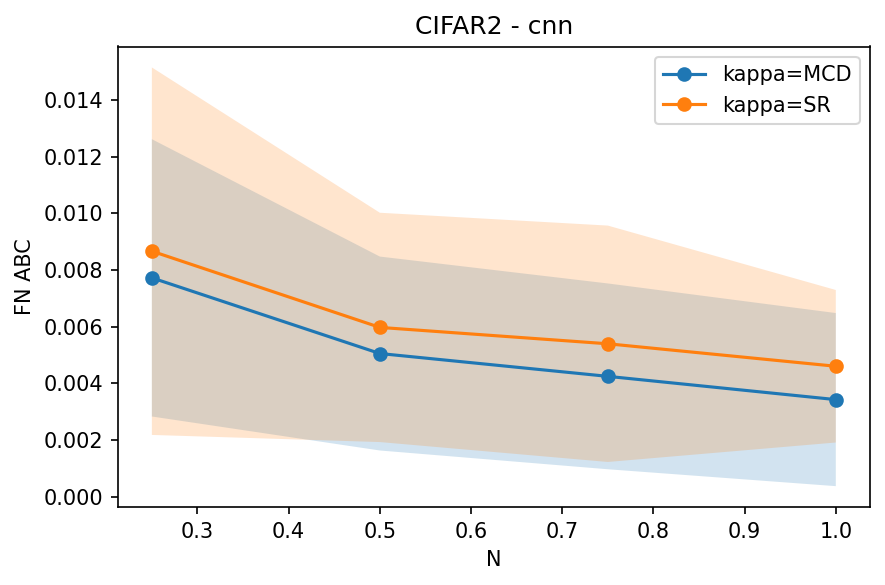

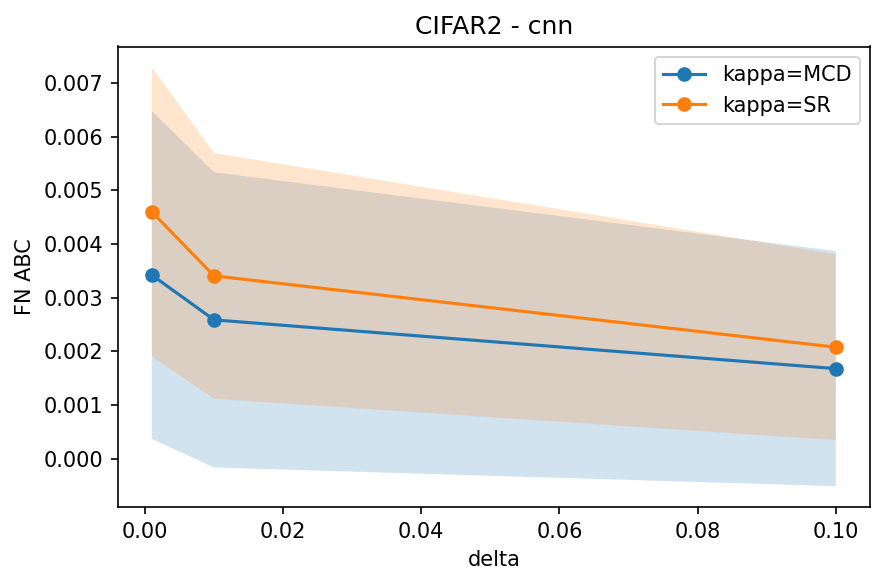

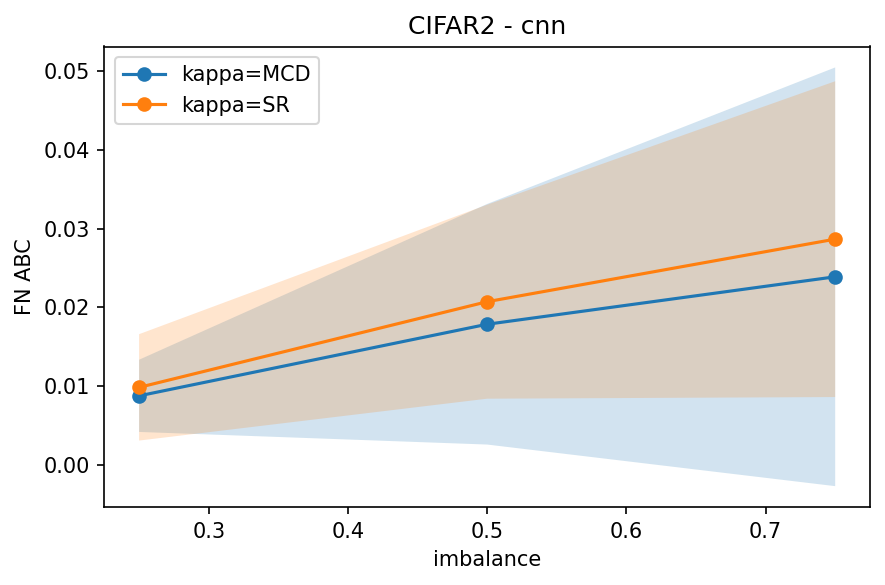

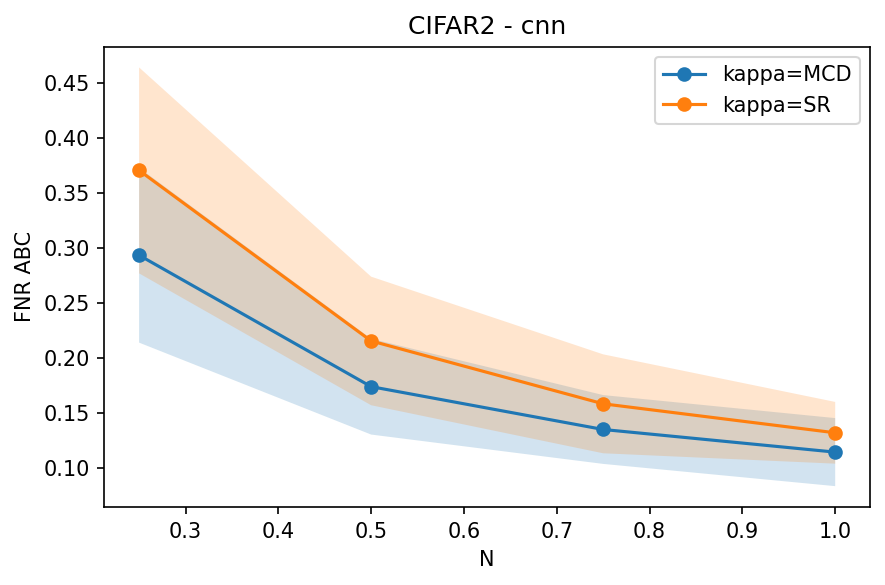

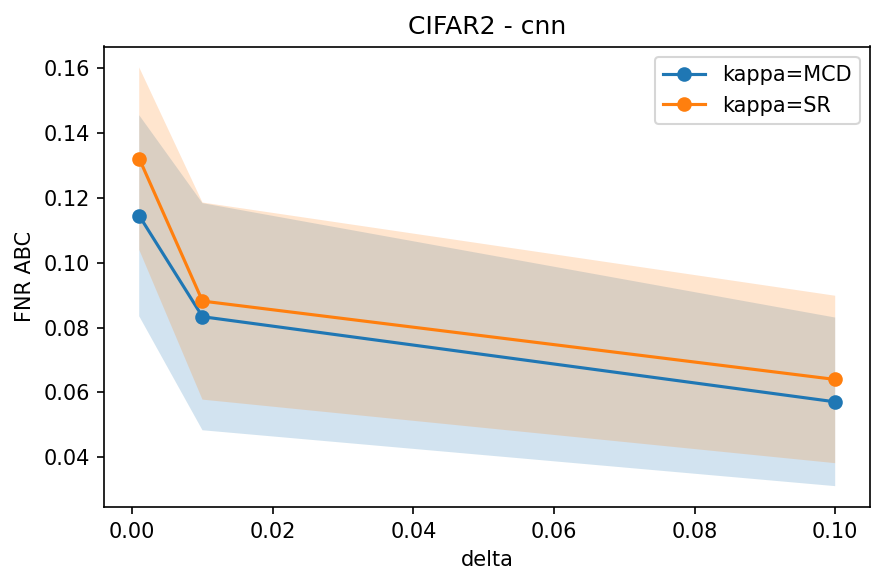

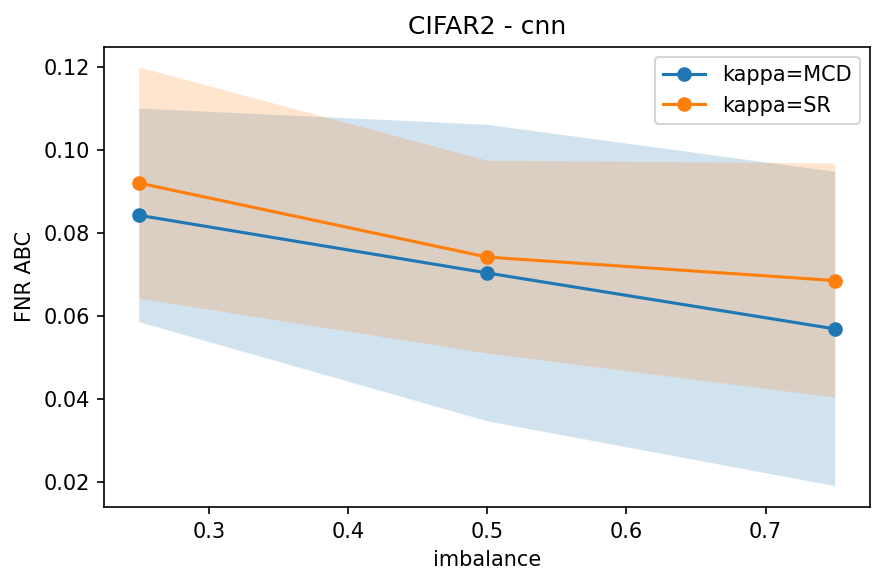

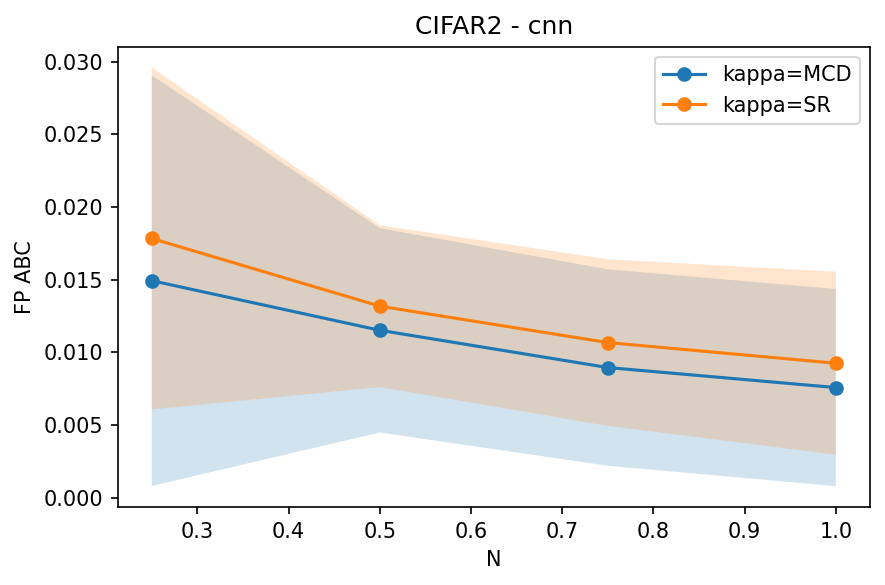

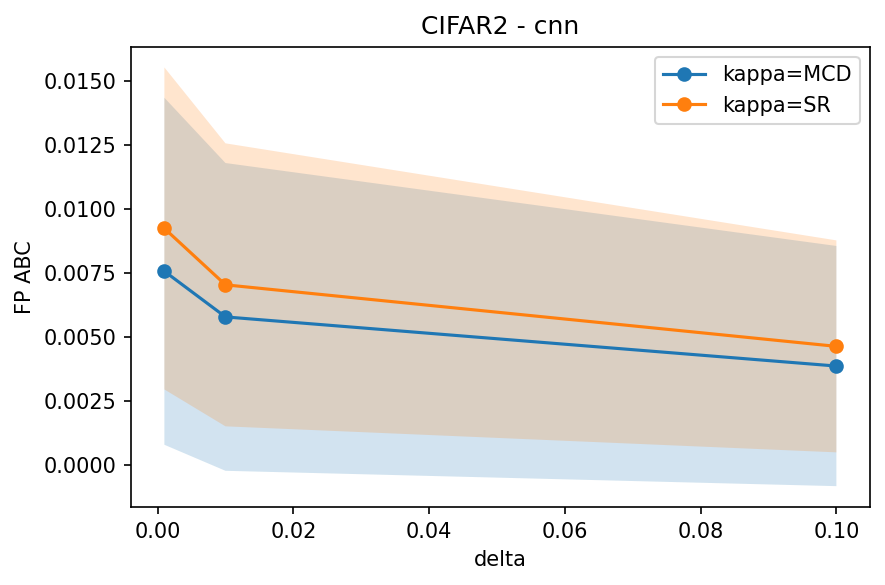

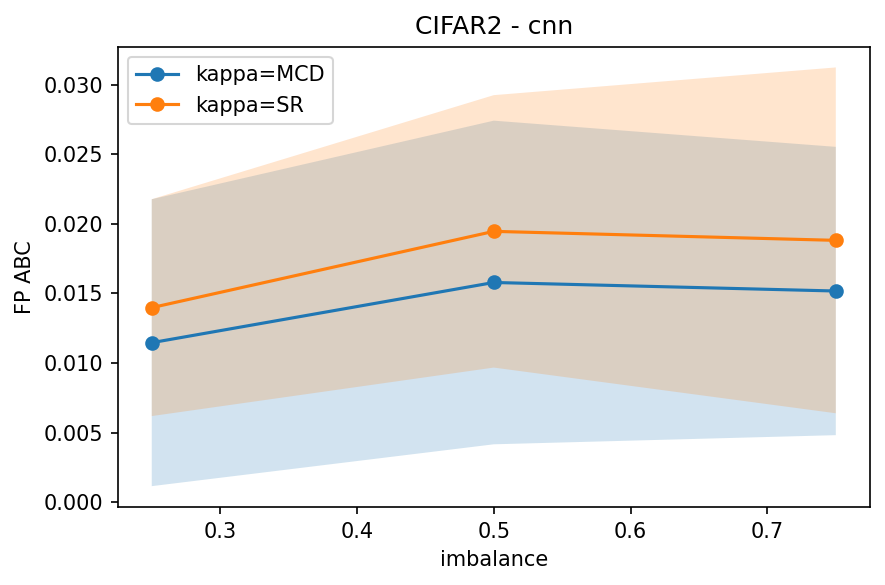

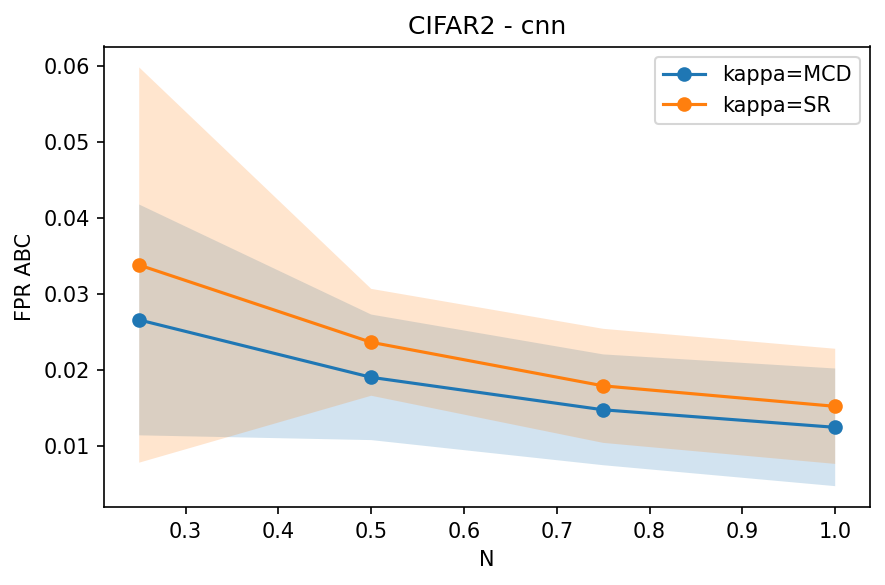

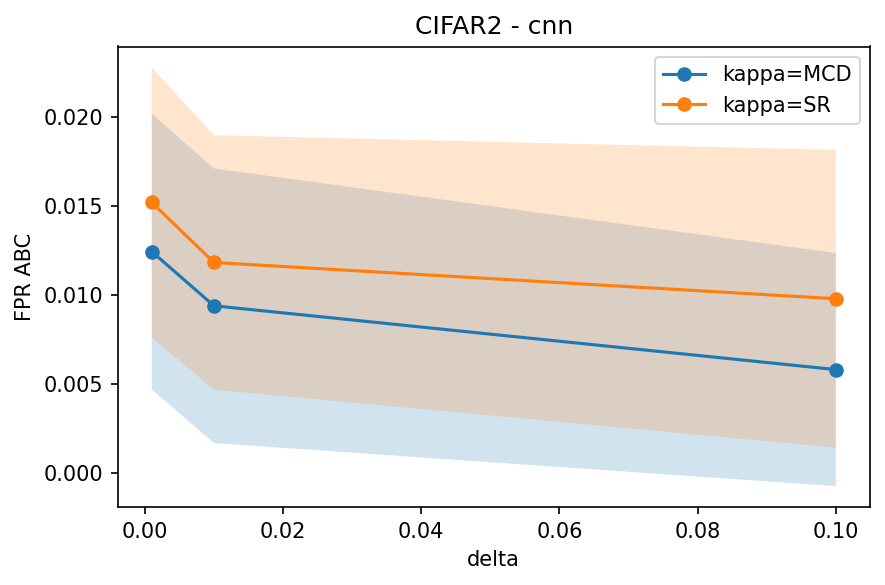

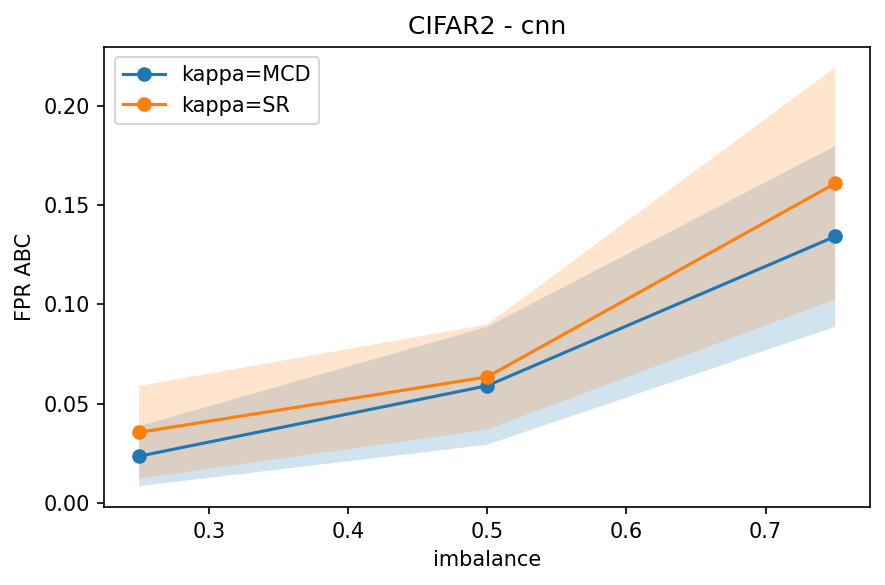

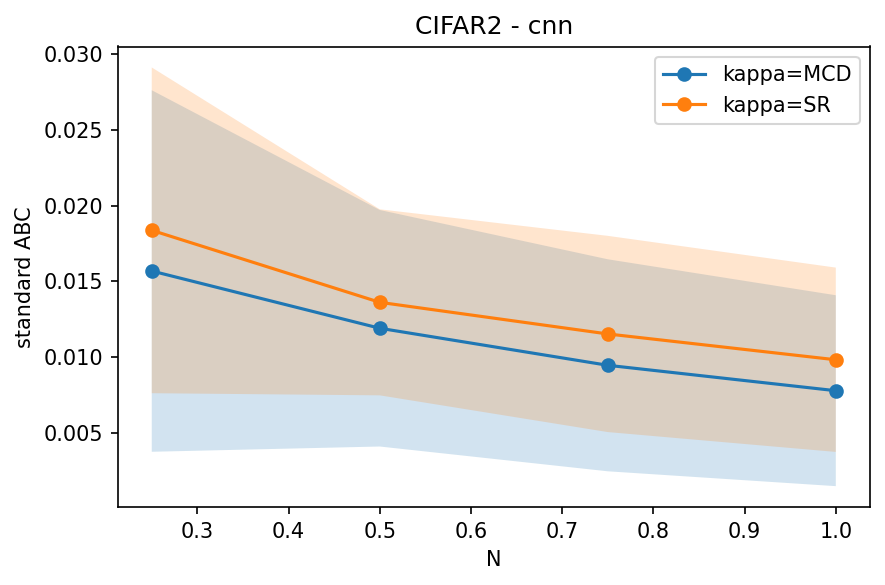

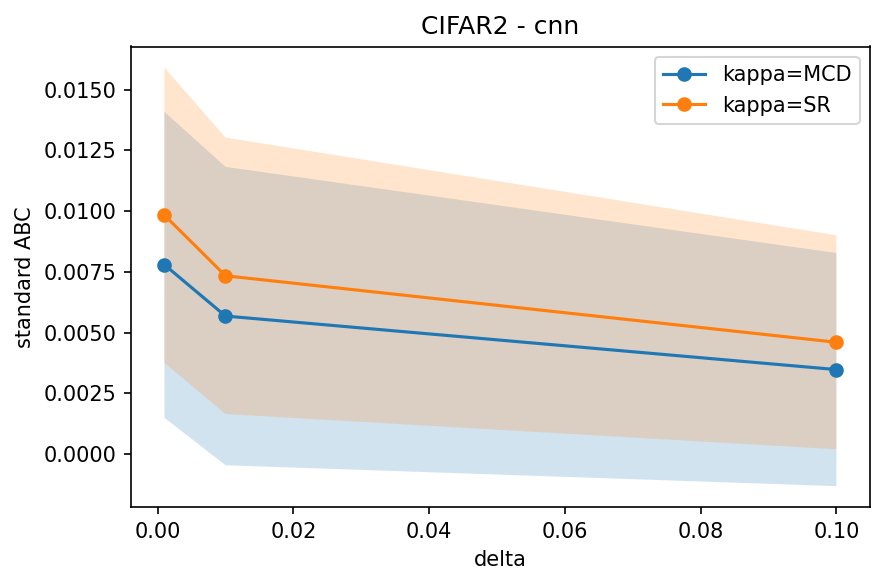

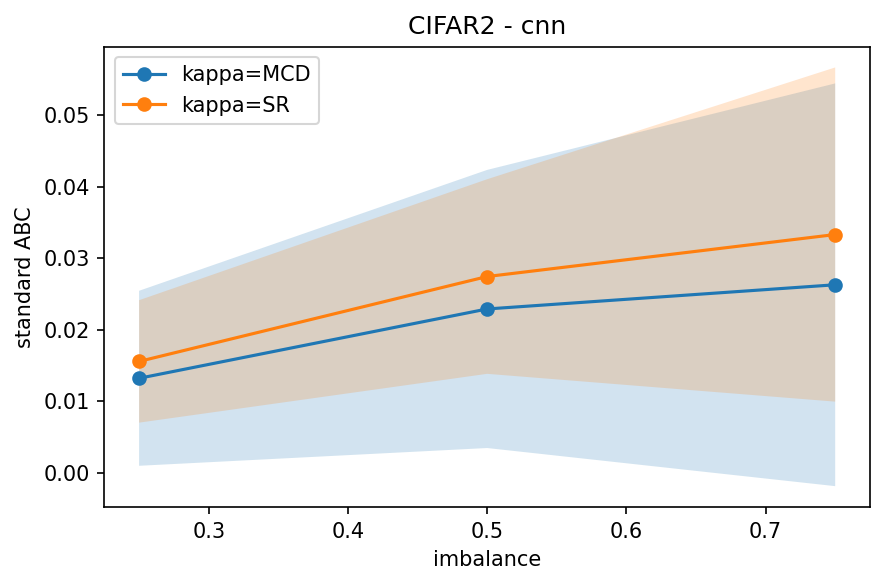

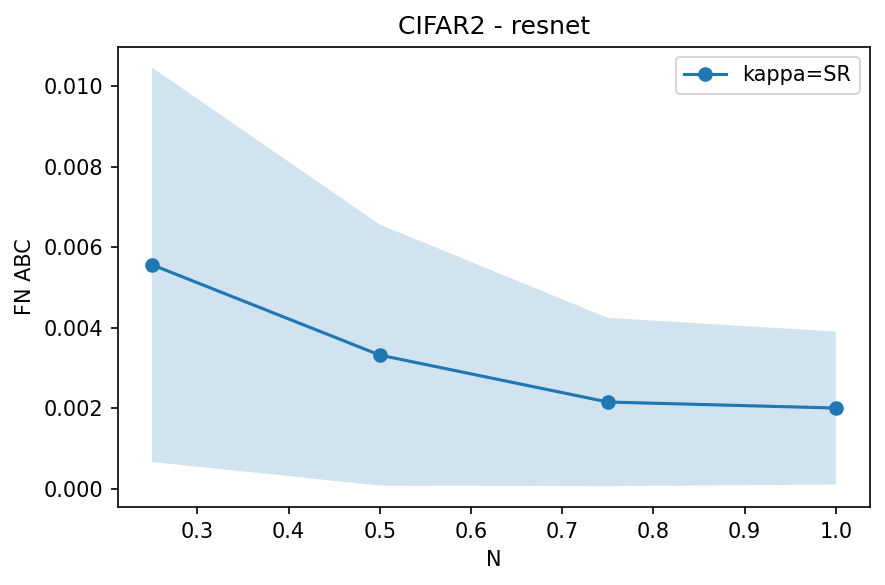

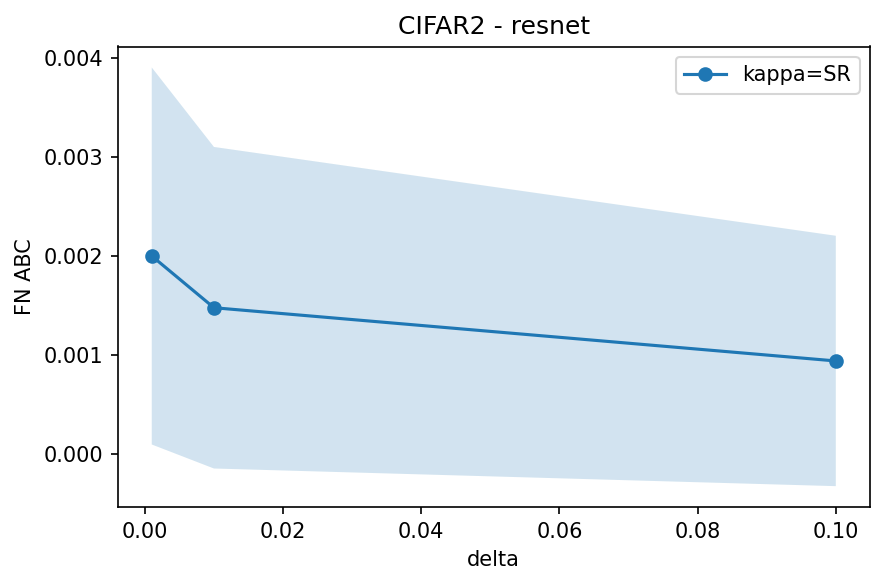

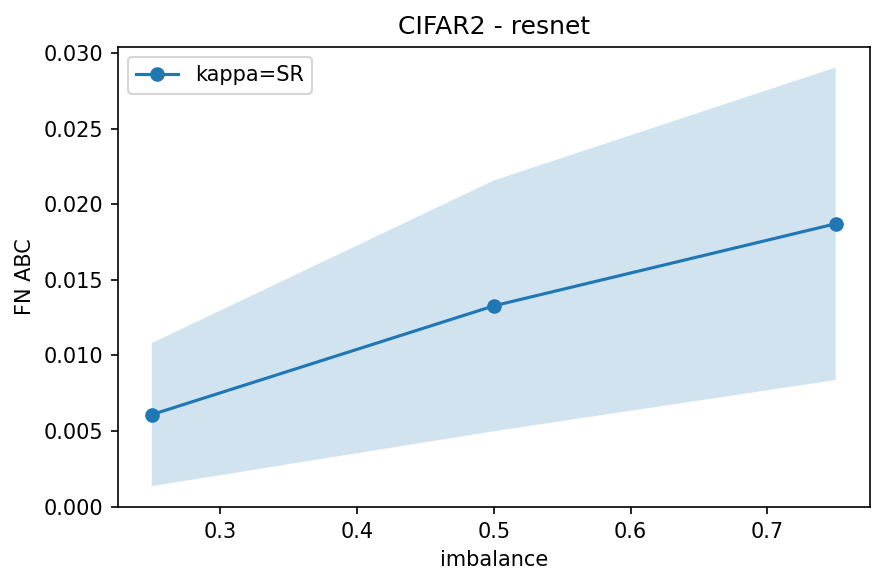

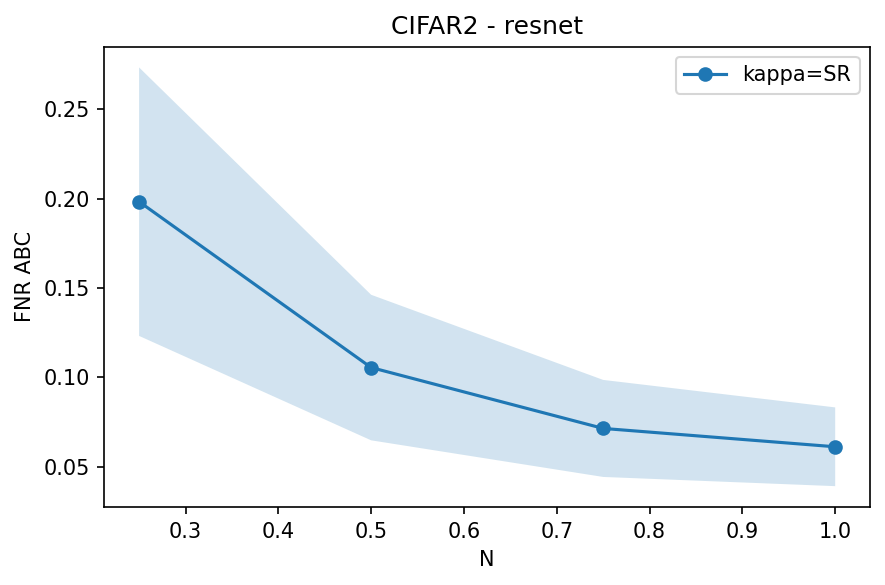

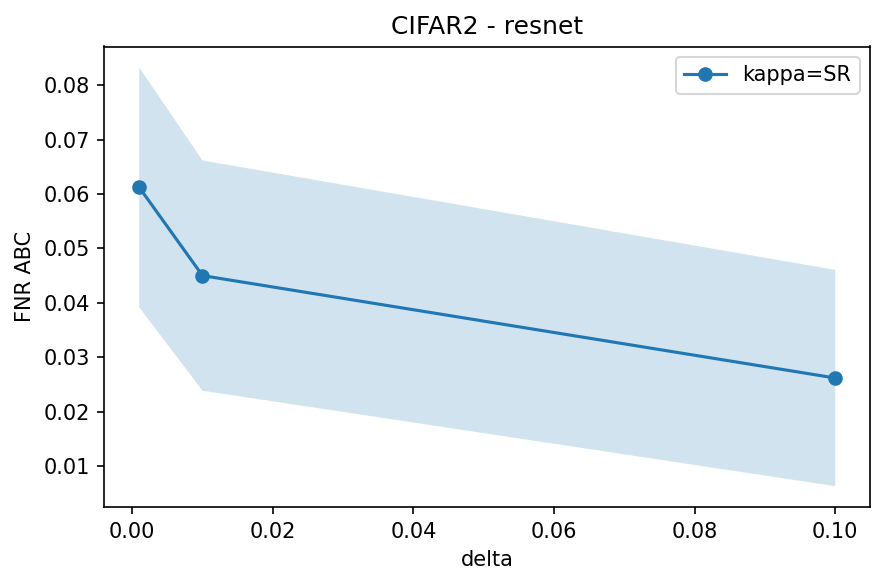

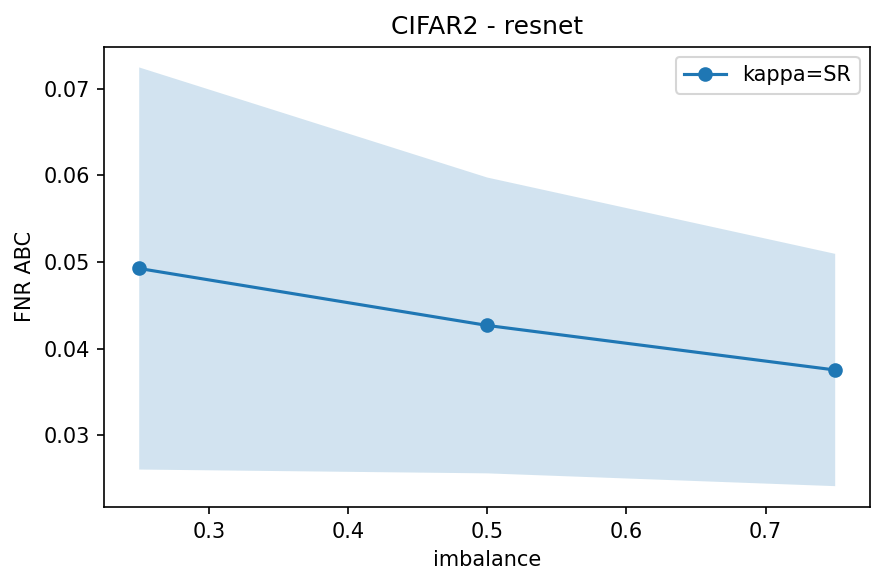

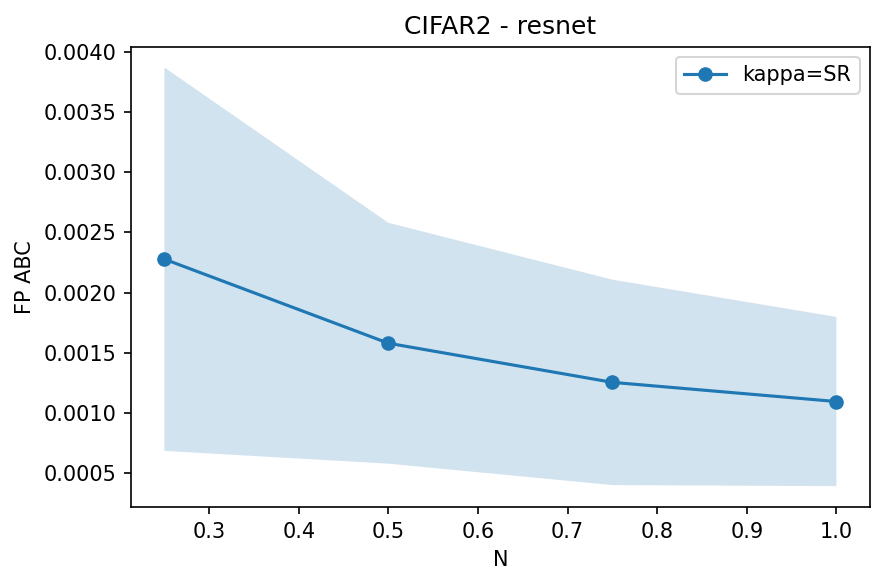

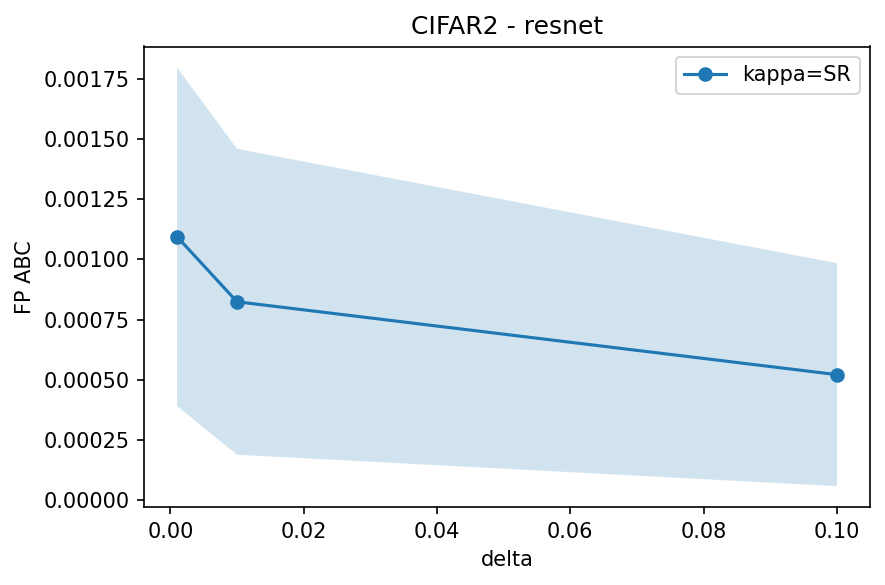

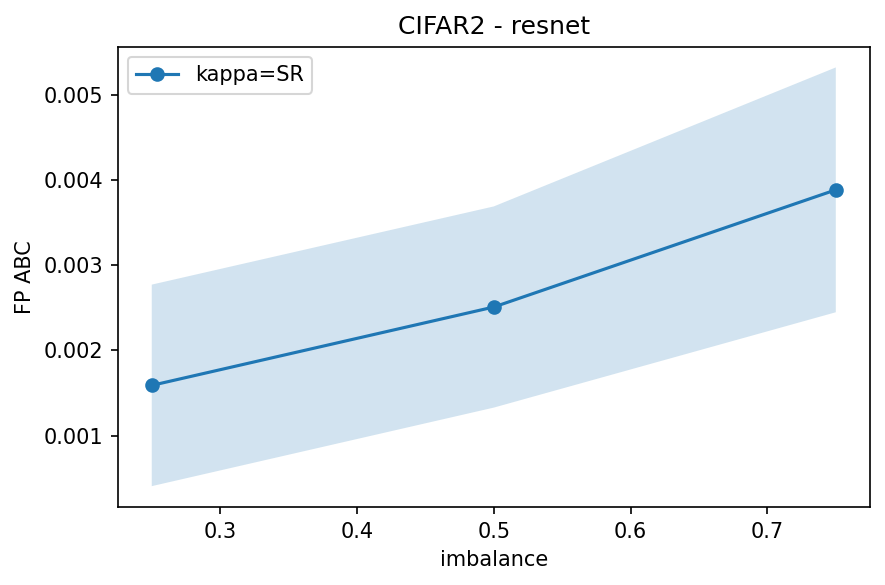

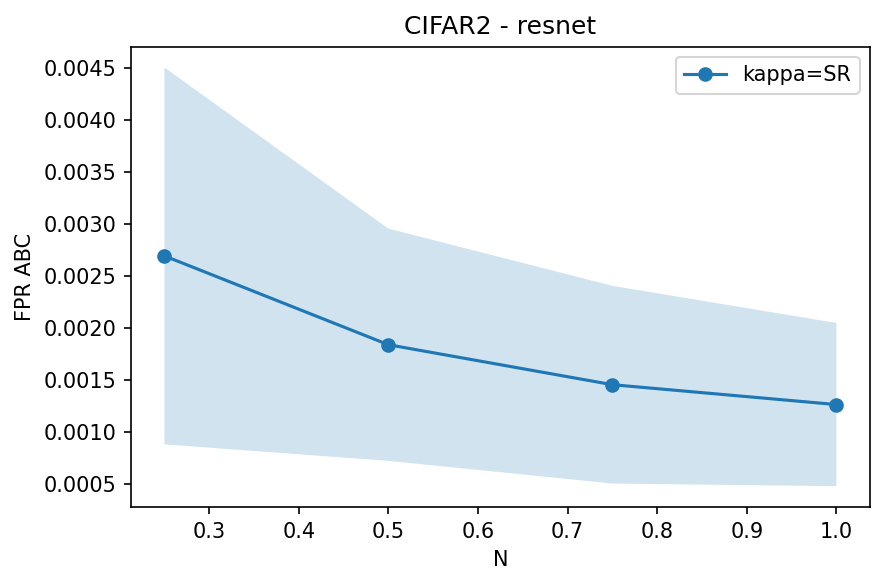

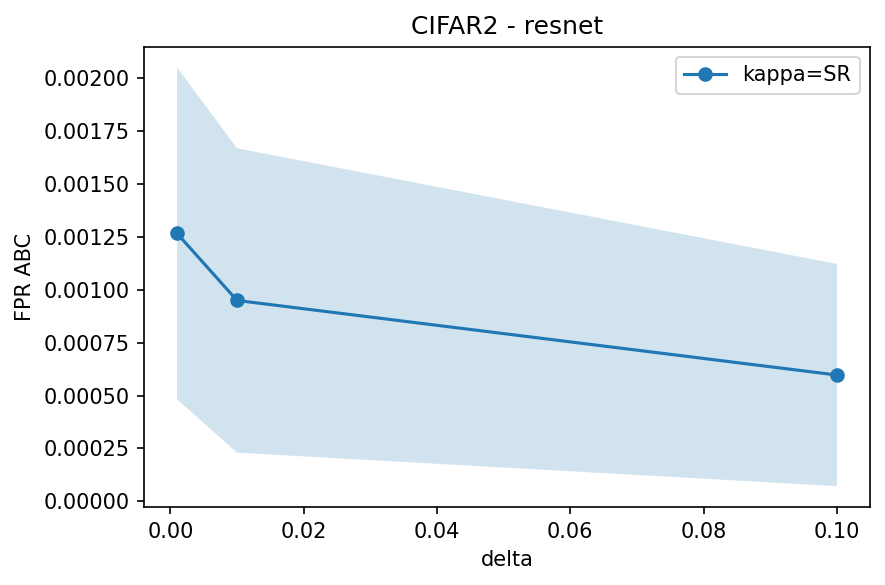

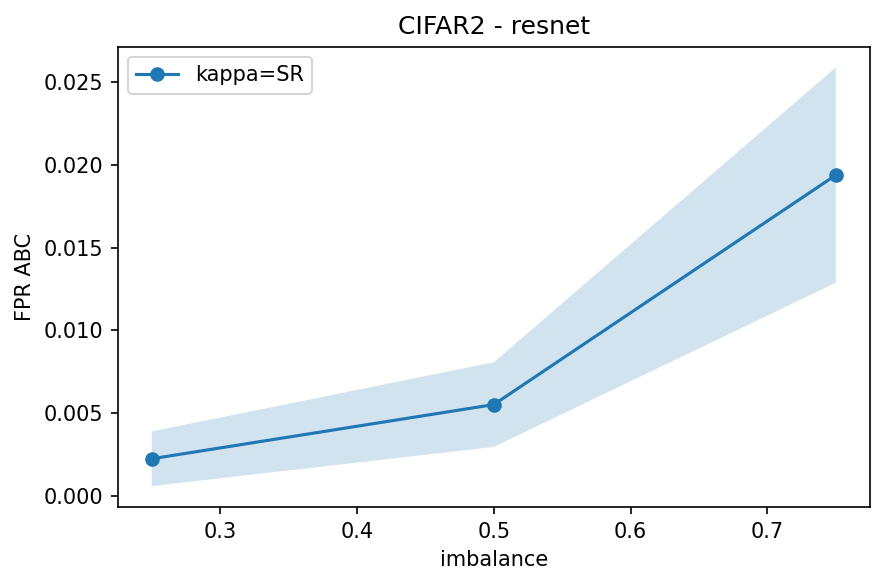

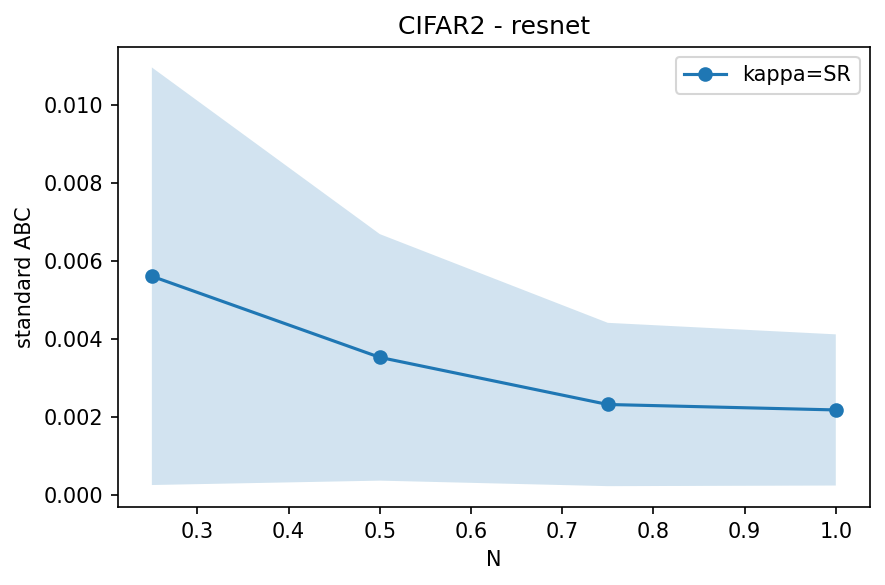

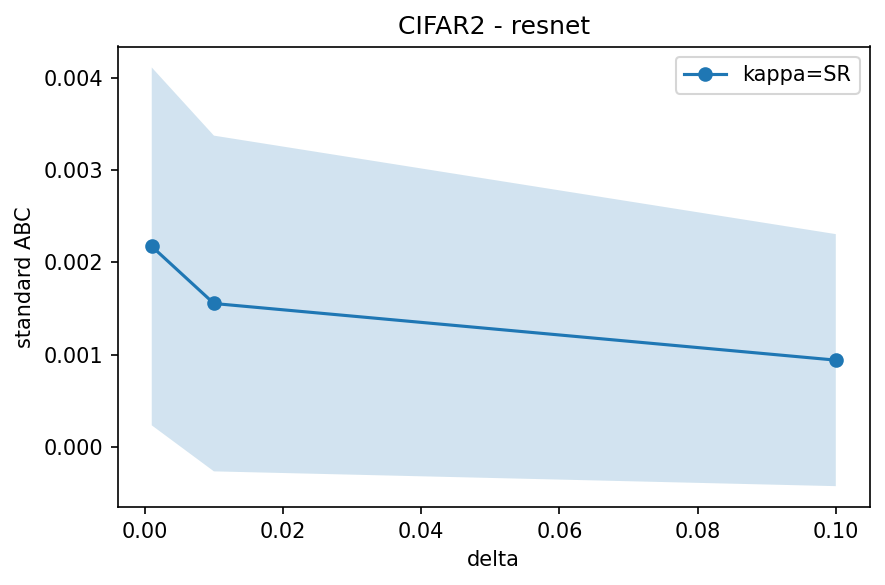

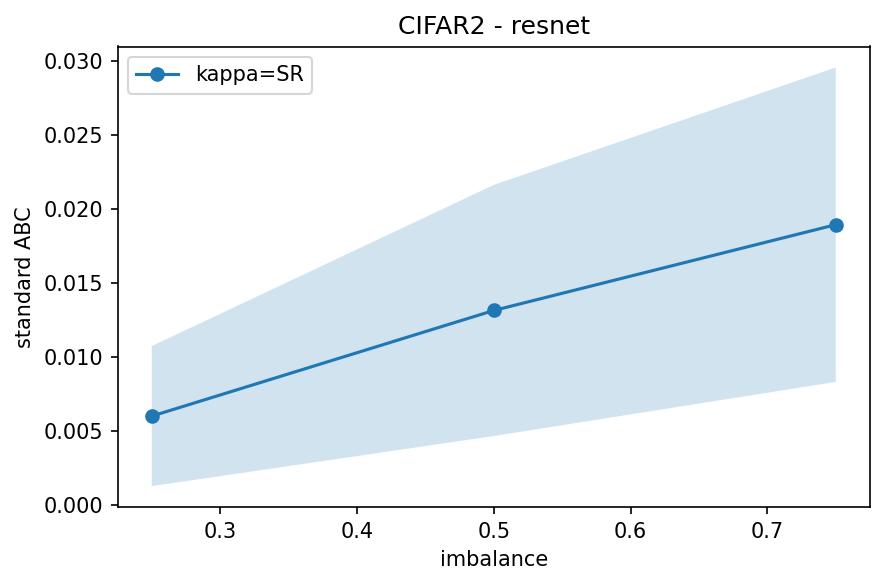

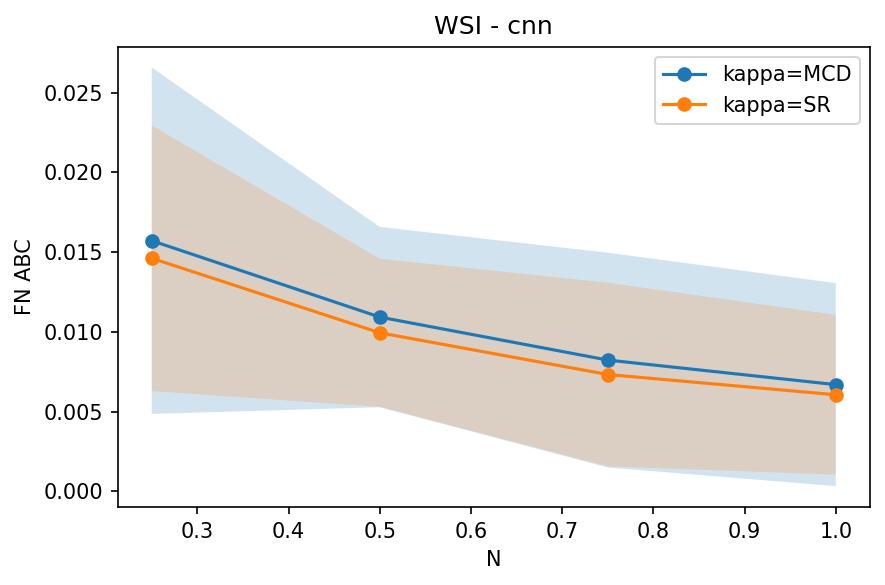

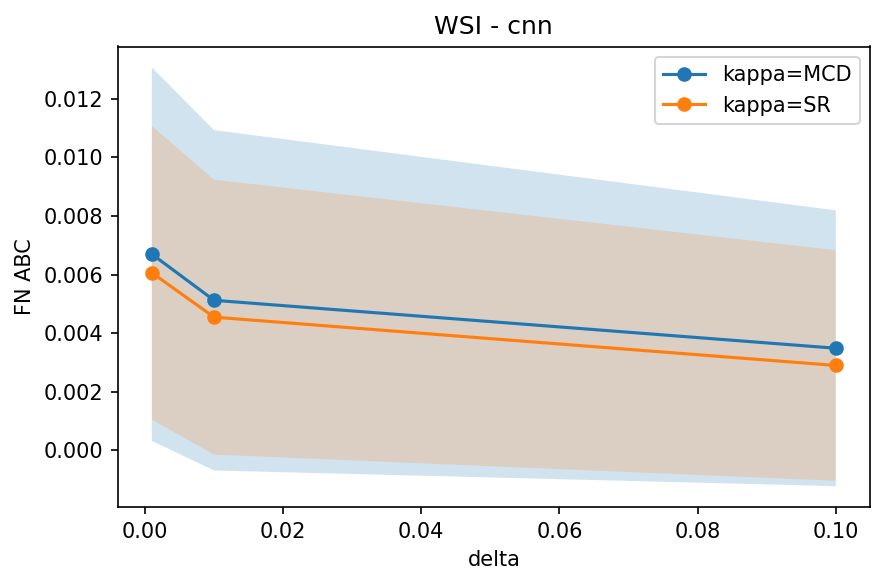

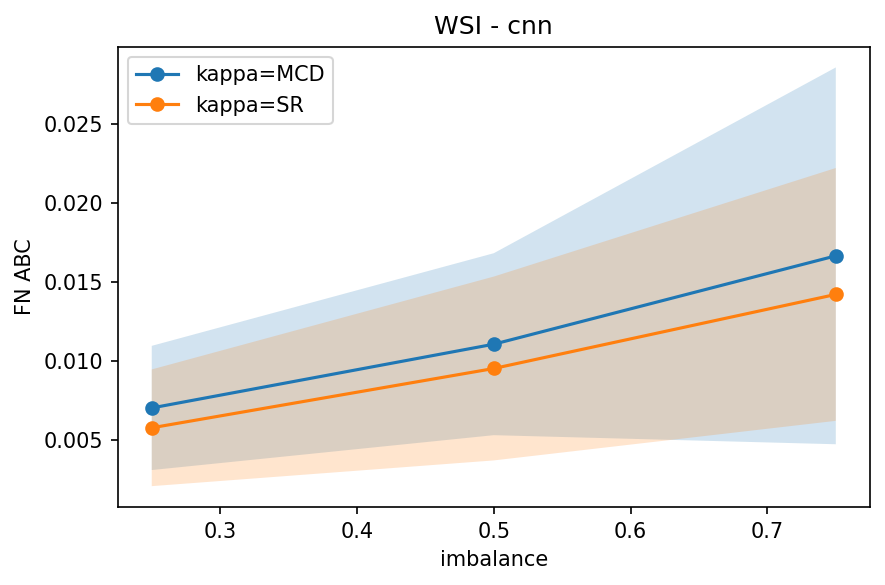

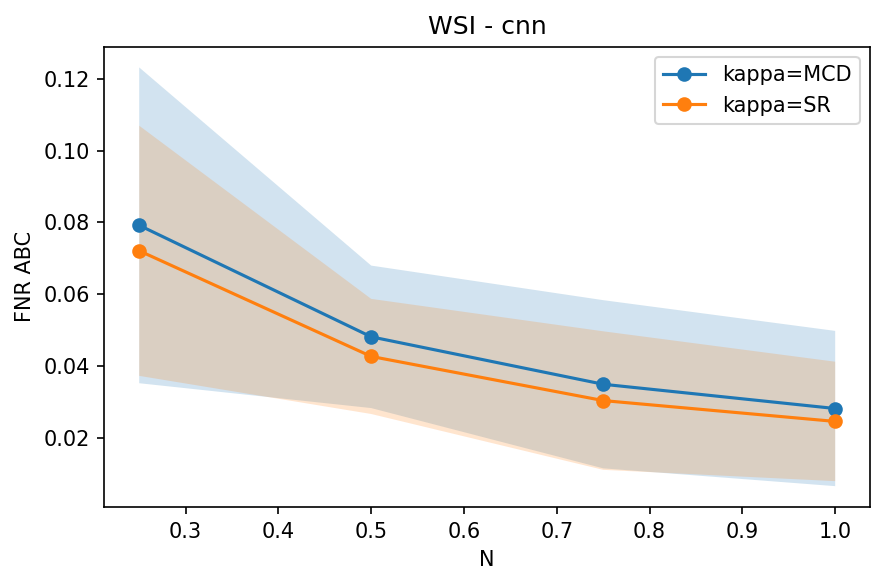

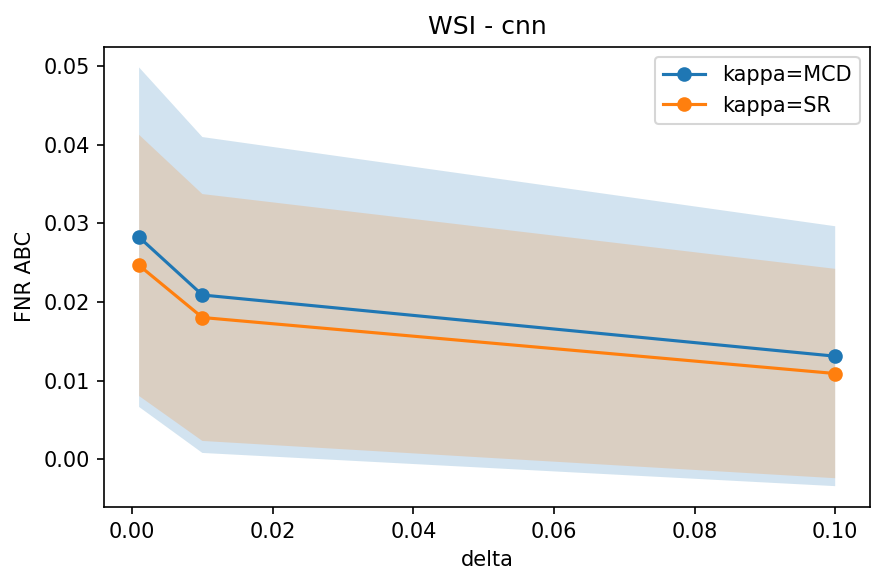

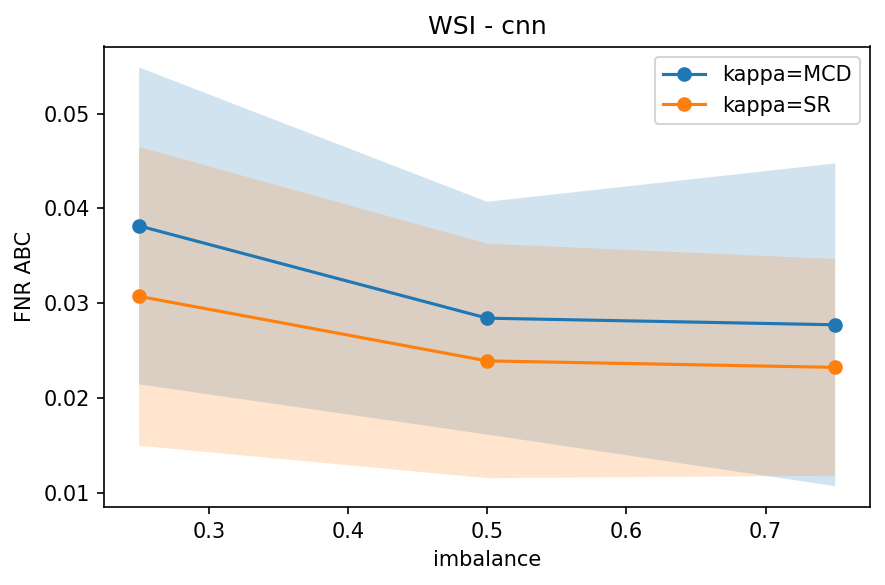

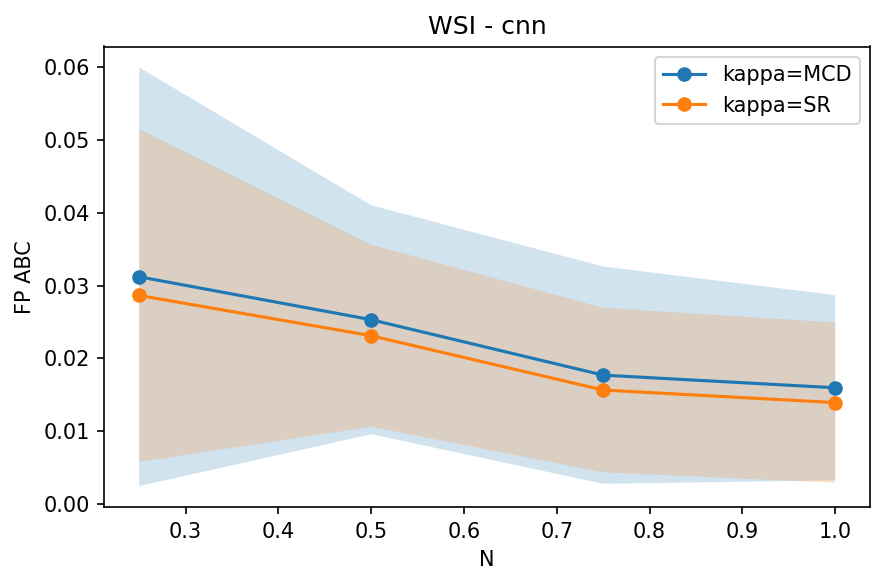

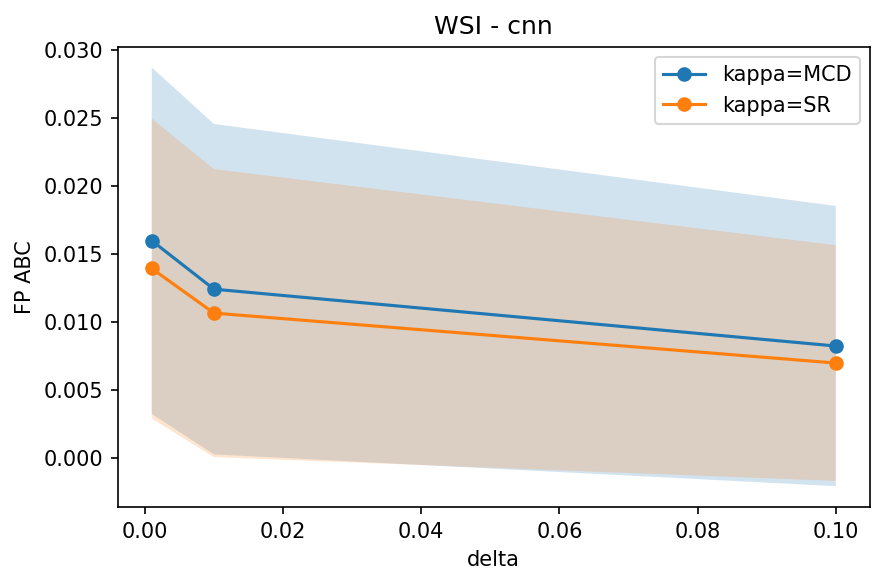

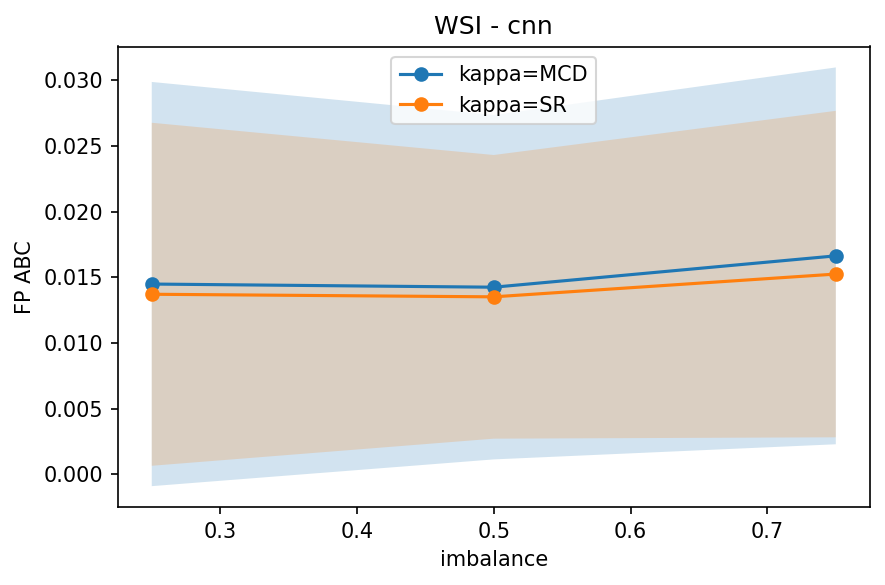

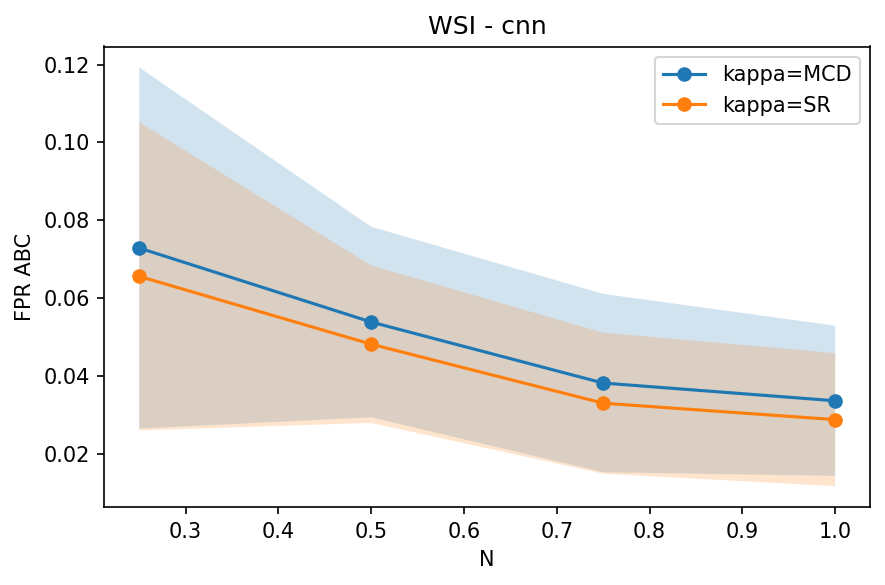

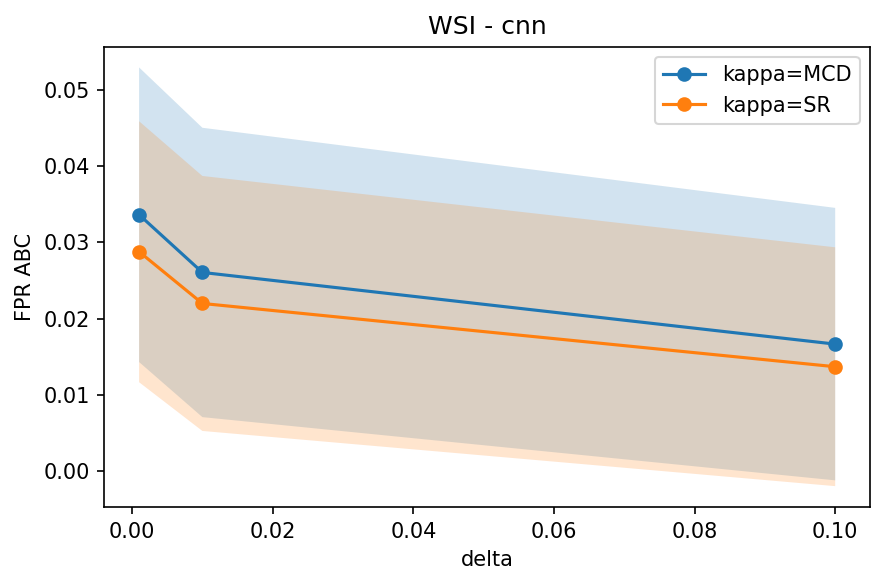

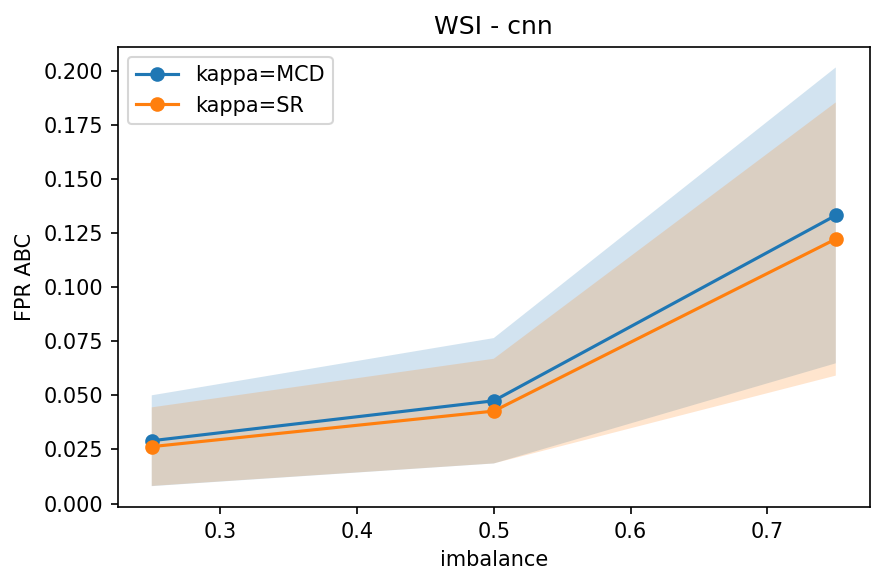

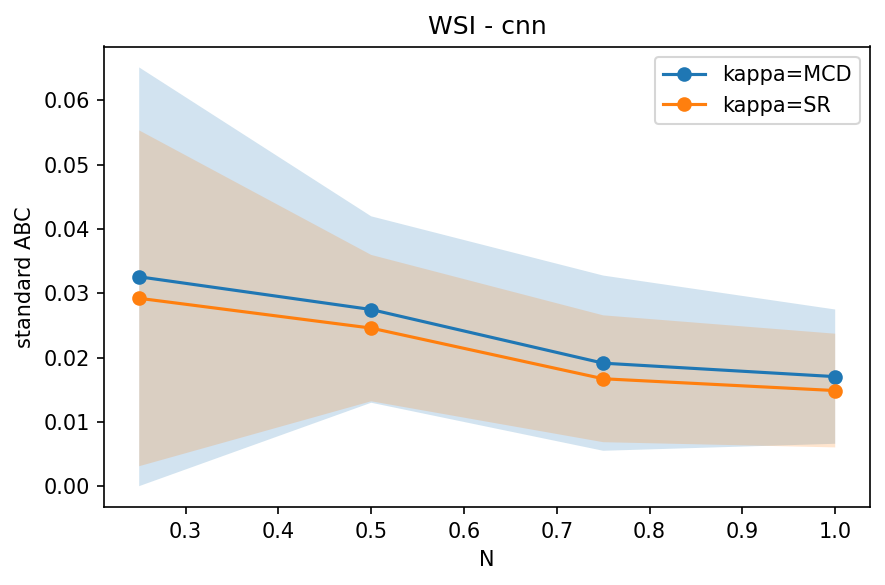

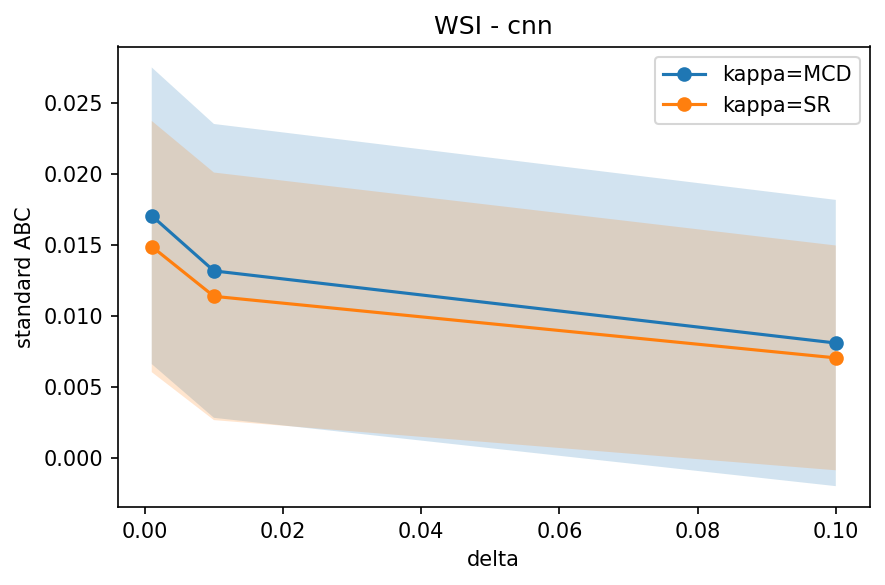

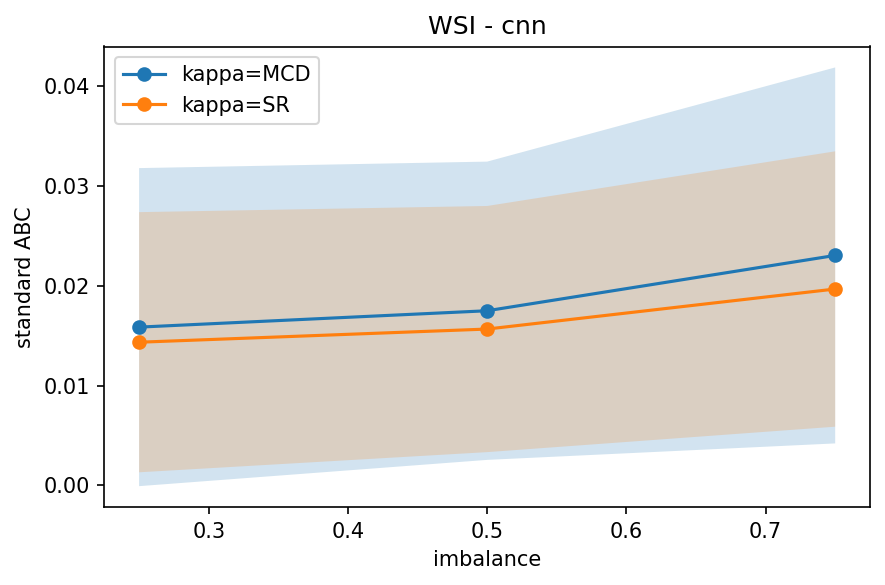

In [12]:
import ast

# Assuming df is your DataFrame
# If CI is stored as string like "[low, high]", convert it to list
if isinstance(df["CI"].iloc[0], str):
    df["CI"] = df["CI"].apply(ast.literal_eval)

# Extract lower and upper bounds from CI
df["CI_low"] = df["CI"].apply(lambda x: x[0])
df["CI_high"] = df["CI"].apply(lambda x: x[1])

# Group by dataset/model/metric/param
grouped = df.groupby(["dataset", "model", "metric", "param."])

for (dataset, model, metric, param), group in grouped:
    plt.figure(figsize=(6, 4))
    
    # plot each kappa
    for kappa, sub in group.groupby("kappa"):
        plt.plot(sub["value"], sub["ABC"], label=f"kappa={kappa}", marker="o")
        plt.fill_between(sub["value"], sub["CI_low"], sub["CI_high"], alpha=0.2)
    
    plt.title(f"{dataset} - {model}")
    plt.xlabel(param)               # x-axis = param name
    plt.ylabel(f"{metric} ABC")     # y-axis = metric + " abc"
    plt.legend()
    plt.tight_layout()
    plt.show()
